In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv("9-email_classification_svm.csv")
df.head()
# Email Classification (Work vs Personal)
# subject_formality_score -> Score based on formality of subject line
# sender_relationship_score -> Score representing how familiar the sender is
# email_type -> 0 = Personal, 1 = Work email

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [65]:
df.isnull().sum()

subject_formality_score      0
sender_relationship_score    0
email_type                   0
dtype: int64

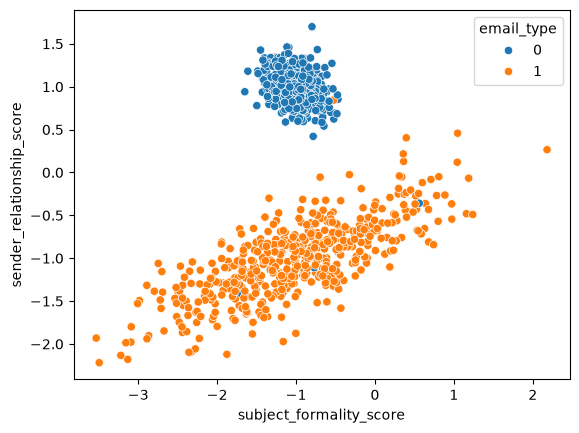

In [66]:
sns.scatterplot(x=df["subject_formality_score"], y=df["sender_relationship_score"],hue=df["email_type"])
plt.show()

In [67]:
df["email_type"].value_counts()

email_type
0    502
1    498
Name: count, dtype: int64

In [68]:
X = df.drop("email_type", axis=1)
y = df["email_type"]

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [70]:
from sklearn.svm import SVC
svc = SVC(kernel="linear")

In [71]:
svc.fit(X_train, y_train)
svc.coef_

array([[ 0.60318833, -1.91645213]])

In [72]:
y_pred = svc.predict(X_test)

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


In [74]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train,y_train)
y_pred = rbf.predict(X_test)
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


New Dataset

In [75]:
df = pd.read_csv("9-loan_risk_svm.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_score_fluctuation   1000 non-null   float64
 1   recent_transaction_volume  1000 non-null   float64
 2   loan_risk                  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [76]:
df.head()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
0,-1.439860,1.283010,1
1,-0.276571,-1.232382,0
2,1.312047,0.955097,1
3,1.020706,0.089485,0
4,1.513729,0.580520,1


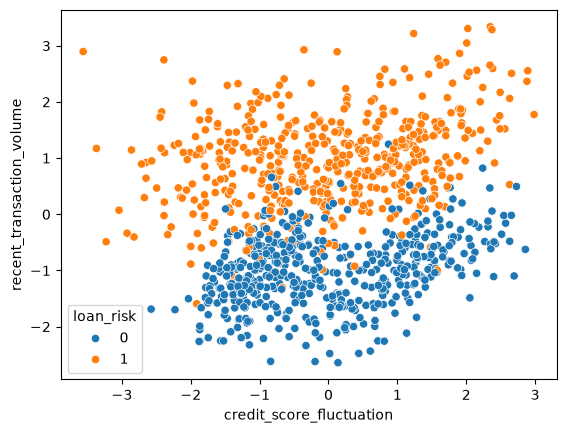

In [77]:
sns.scatterplot(x=df["credit_score_fluctuation"], y= df["recent_transaction_volume"], hue= df["loan_risk"])
plt.show()

In [78]:
X = df.drop("loan_risk", axis=1)
y = df["loan_risk"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [80]:
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred3 = linear.predict(X_test)
print(classification_report(y_pred3, y_test))
print(confusion_matrix(y_pred3,y_test))


              precision    recall  f1-score   support

           0       0.90      0.92      0.91       118
           1       0.93      0.91      0.92       132

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[109   9]
 [ 12 120]]


In [81]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred4 = rbf.predict(X_test)
print(classification_report(y_pred4, y_test))
print(confusion_matrix(y_pred4,y_test))


              precision    recall  f1-score   support

           0       0.93      0.91      0.92       124
           1       0.91      0.94      0.93       126

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[113  11]
 [  8 118]]


In [82]:
poly = SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred5 = poly.predict(X_test)
print(classification_report(y_pred5, y_test))
print(confusion_matrix(y_pred5,y_test))


              precision    recall  f1-score   support

           0       0.88      0.93      0.91       115
           1       0.94      0.90      0.92       135

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[107   8]
 [ 14 121]]


In [83]:
sigmoid = SVC(kernel="sigmoid")
sigmoid.fit(X_train, y_train)
y_pred6 = sigmoid.predict(X_test)
print(classification_report(y_pred6, y_test))
print(confusion_matrix(y_pred6 ,y_test))


              precision    recall  f1-score   support

           0       0.81      0.83      0.82       118
           1       0.84      0.83      0.84       132

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

[[ 98  20]
 [ 23 109]]


HYPERPARAMETER TUNING

In [84]:
param_grid = {
    "C" : [0.1, 1, 10, 100, 1000],
    "kernel": ["rbf"],
    "gamma": ["scale","auto"]
}

In [85]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator= SVC(), param_grid= param_grid, cv= 5)
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during f

In [86]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [ ]:

y_pred7 = grid.predict(X_test)
print(classification_report(y_pred7, y_test))
print(confusion_matrix(y_pred7 ,y_test))


              precision    recall  f1-score   support

           0       0.93      0.92      0.92       122
           1       0.92      0.93      0.93       128

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[112  10]
 [  9 119]]


NEW DATASET


In [88]:
df = pd.read_csv("9-seismic_activity_svm.csv")
df.head()
# Seismic Activity Classification
# underground_wave_energy -> Energy level of underground seismic wave (high variance)
# vibration_axis_variation -> Localized vibration variation on a vertical axis
# seismic_event_detected -> 1 = Seismic Event, 0 = No event (binary classification)

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [90]:
df["seismic_event_detected"].value_counts()

seismic_event_detected
0    200
1    200
Name: count, dtype: int64

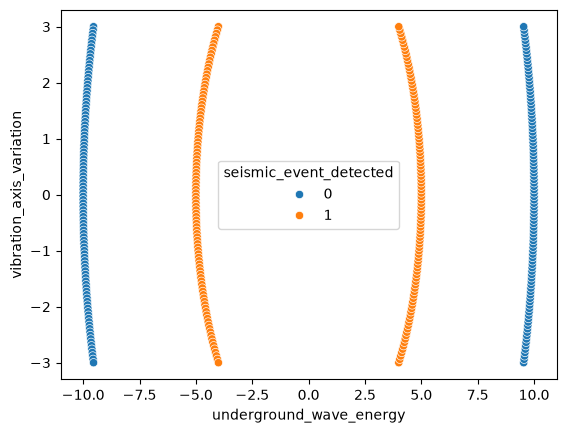

In [91]:
sns.scatterplot(x=df["underground_wave_energy"],y= df["vibration_axis_variation"], hue= df["seismic_event_detected"])
plt.show()
#REQUIRES 3D VISUALISATION

In [92]:
df["underground_wave_energy ** 2"] = df["underground_wave_energy"] ** 2
df["vibration_axis_variation ** 2"] = df["vibration_axis_variation"] ** 2
df["underground_wave_energy * vibration_axis_variation"] = (df["underground_wave_energy"] * df["vibration_axis_variation"])

In [93]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy ** 2,vibration_axis_variation ** 2,underground_wave_energy * vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,9.000000,-28.618176
1,9.558241,-2.939394,0,91.359963,8.640037,-28.095434
2,9.576669,-2.878788,0,91.712580,8.287420,-27.569197
3,9.594678,-2.818182,0,92.057851,7.942149,-27.039548
4,9.612272,-2.757576,0,92.395776,7.604224,-26.506569


In [94]:
X = df.drop("seismic_event_detected", axis=1)
y= df["seismic_event_detected"]

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)
X_train

,underground_wave_energy,vibration_axis_variation,underground_wave_energy ** 2,vibration_axis_variation ** 2,underground_wave_energy * vibration_axis_variation
135,-9.961312,0.878788,99.227732,0.772268,-8.753880
170,-9.922519,-1.242424,98.456382,1.543618,12.327978
368,-4.872667,-1.121212,23.742883,1.257117,5.463293
77,9.860133,1.666667,97.222222,2.777778,16.433555
12,9.738311,-2.272727,94.834711,5.165289,-22.132526
...,...,...,...,...,...
384,-4.541817,-2.090909,20.628099,4.371901,9.496526
375,-4.755162,-1.545455,22.611570,2.388430,7.348887
133,-9.949874,1.000000,99.000000,1.000000,-9.949874
396,-4.130115,-2.818182,17.057851,7.942149,11.639415


In [100]:
'''
import plotly.express as px
fig = px.scatter_3d(df, x='underground_wave_energy **2', y='vibration_axis_variation **2', z='underground_wave_energy*vibration_axis_variation',
              color='seismic_event_detected')
fig.show()
'''

"\nimport plotly.express as px\nfig = px.scatter_3d(df, x='underground_wave_energy **2', y='vibration_axis_variation **2', z='underground_wave_energy*vibration_axis_variation',\n              color='seismic_event_detected')\nfig.show()\n"

In [101]:
linear = SVC(kernel="linear")
linear.fit(X_train,y_train)
y_pred8 = linear.predict(X_test)
print(classification_report(y_pred8, y_test))
print(confusion_matrix(y_pred8 ,y_test))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]


In [102]:
#AUTOMATIC RBF
df = pd.read_csv("9-seismic_activity_svm.csv")
X=df.drop('seismic_event_detected',axis=1)
y=df['seismic_event_detected']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [ ]:
linear=SVC(kernel='linear')
linear.fit(X_train,y_train)
y_pred9=linear.predict(X_test)
print(classification_report(y_test,y_pred9))
print(confusion_matrix(y_test,y_pred9))

#linear does not give a good score as expected

              precision    recall  f1-score   support

           0       0.48      1.00      0.65        48
           1       0.00      0.00      0.00        52

    accuracy                           0.48       100
   macro avg       0.24      0.50      0.32       100
weighted avg       0.23      0.48      0.31       100

[[48  0]
 [52  0]]


c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [104]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred11=rbf.predict(X_test)
print(classification_report(y_test,y_pred11))
print(confusion_matrix(y_test,y_pred11))

#rbf gives the same score automatically

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]
